# Analyse : faux positifs, mémoire et complexité

Ce notebook regroupe les analyses critiques demandées :
1. impact des **faux positifs** du filtre de Bloom (chemins fantômes),
2. comparaison de la **consommation mémoire** filtre de Bloom vs dictionnaire,
3. note sur la **complexité** de l'alignement O(n^2) face à l'approche par graphe.

In [ ]:
import sys
import os

sys.path.insert(0, os.path.abspath(".."))

from src.io_sequences import lire_fastq, lire_fasta
from src.kmers import compter_kmers, kmers_solides
from src.bloom import FiltreBloom, taille_optimale, proba_faux_positif_theorique
from src.assemblage import construire_contig, meilleure_identite

import matplotlib.pyplot as plt

if not os.path.exists("../data/toy_reads.fastq"):
    from src.generer_toy import generer_toy
    generer_toy()

reads = lire_fastq("../data/toy_reads.fastq")
reference = lire_fasta("../data/reference.fasta")[0][1]

# On prepare l'ensemble des k-mers solides une fois pour toutes
k = 21
seuil = 5
comptage = compter_kmers(reads, k)
solides = kmers_solides(comptage, seuil)
print("Nombre de k-mers solides :", len(solides))

Nombre de k-mers solides : 379


## 1. Impact des faux positifs (chemins fantômes)

Un faux positif fait croire qu'un k-mer existe alors qu'il n'existe pas. Pendant
la traversée, cela peut créer une **fausse bifurcation** (et donc casser un contig)
ou un **chemin fantôme**. On fait varier le taux de faux positifs visé et on
observe le nombre de contigs et l'identité finale.

In [ ]:
def assembler_avec_p(solides, p):
    """Assemble en utilisant un filtre de Bloom avec un taux de faux positifs vise p."""
    m, kh = taille_optimale(len(solides), p)
    filtre = FiltreBloom(m, kh)
    for kmer in solides:
        filtre.ajouter(kmer)

    contigs = []
    visites = set()
    for seed in solides:
        if seed in visites:
            continue
        contigs.append(construire_contig(filtre, seed, visites))
    contigs.sort(key=len, reverse=True)
    return contigs, m, kh

liste_p = [0.1, 0.05, 0.01, 0.001, 0.0001, 0.00001]
nb_contigs_par_p = []
identite_par_p = []

print("p vise   | m bits | k | nb contigs | identite")
print("-" * 55)
for p in liste_p:
    contigs, m, kh = assembler_avec_p(solides, p)
    ident = meilleure_identite(contigs, reference)
    nb_contigs_par_p.append(len(contigs))
    identite_par_p.append(ident)
    print("%8.5f | %6d | %d | %10d | %.1f%%" % (p, m, kh, len(contigs), ident))

p vise   | m bits | k | nb contigs | identite
-------------------------------------------------------


 0.10000 |   1817 | 3 |        105 | 9.0%
 0.05000 |   2364 | 4 |         69 | 10.8%


 0.01000 |   3633 | 7 |          9 | 39.2%
 0.00100 |   5450 | 10 |          1 | 99.8%
 0.00010 |   7266 | 13 |          1 | 99.8%
 0.00001 |   9082 | 17 |          1 | 99.8%


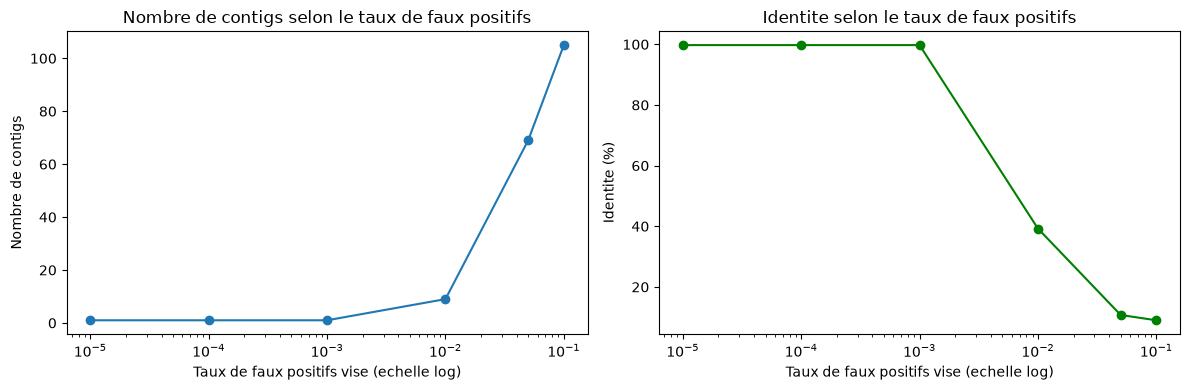

Conclusion : plus le taux de faux positifs est eleve, plus l'assemblage
est fragmente (beaucoup de contigs) et moins l'identite est bonne.


In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(liste_p, nb_contigs_par_p, marker="o")
ax1.set_xscale("log")
ax1.set_title("Nombre de contigs selon le taux de faux positifs")
ax1.set_xlabel("Taux de faux positifs vise (echelle log)")
ax1.set_ylabel("Nombre de contigs")

ax2.plot(liste_p, identite_par_p, marker="o", color="green")
ax2.set_xscale("log")
ax2.set_title("Identite selon le taux de faux positifs")
ax2.set_xlabel("Taux de faux positifs vise (echelle log)")
ax2.set_ylabel("Identite (%)")

plt.tight_layout()
plt.show()

print("Conclusion : plus le taux de faux positifs est eleve, plus l'assemblage")
print("est fragmente (beaucoup de contigs) et moins l'identite est bonne.")

## 2. Consommation mémoire : filtre de Bloom vs dictionnaire

Le filtre de Bloom stocke seulement des bits, alors qu'un `set`/`dict` stocke
les chaînes de k-mers entières. On compare les deux.

In [ ]:
import sys

# Memoire d'un set Python contenant tous les k-mers solides
ensemble = set(solides)
memoire_set = sys.getsizeof(ensemble)
for kmer in ensemble:
    memoire_set = memoire_set + sys.getsizeof(kmer)

# Memoire du filtre de Bloom (1 octet par case dans notre implementation)
m, kh = taille_optimale(len(solides), 0.000001)
filtre = FiltreBloom(m, kh)
memoire_bloom = sys.getsizeof(filtre.bits)

print("Nombre de k-mers solides :", len(solides))
print()
print("Memoire approximative du set    :", memoire_set, "octets")
print("Memoire approximative du Bloom  :", memoire_bloom, "octets")
print()
# Version theorique : un filtre de Bloom optimise utilise 1 bit (et non 1 octet) par case
memoire_bloom_bits = m / 8
print("Memoire theorique du Bloom (1 bit/case) : %.0f octets" % memoire_bloom_bits)
print()
print("Le filtre de Bloom ne stocke jamais les k-mers eux-memes :")
print("sa taille ne depend pas de la longueur k, contrairement au set.")

Nombre de k-mers solides : 379

Memoire approximative du set    : 40098 octets
Memoire approximative du Bloom  : 10956 octets

Memoire theorique du Bloom (1 bit/case) : 1362 octets

Le filtre de Bloom ne stocke jamais les k-mers eux-memes :
sa taille ne depend pas de la longueur k, contrairement au set.


## 3. Complexité : alignement O(n^2) vs approche par graphe

**Alignement par programmation dynamique (Lot 2)**
- Temps : O(n * m) pour deux séquences de longueurs n et m. Pour des reads de
  longueur n, c'est de l'ordre de O(n^2).
- Espace : O(n * m) pour la table complète (ou O(min(n, m)) si on ne garde que
  deux lignes, comme dans notre mesure d'identité).
- Comparer toutes les paires de R reads coûterait O(R^2 * n^2), ce qui devient
  vite impossible pour des millions de reads.

**Approche par graphe implicite + filtre de Bloom (Lot 3)**
- On ne compare plus les reads deux à deux. On découpe en k-mers (O(longueur totale))
  et on parcourt le graphe en testant les extensions.
- Le test d'appartenance au filtre de Bloom est en O(k_hachages), soit un coût
  quasi constant, et la mémoire est constante (m bits) quelle que soit la longueur
  des k-mers.

Le tableau ci-dessous résume la comparaison.

In [ ]:
print("Comparaison de complexite")
print("=" * 60)
print("%-22s | %-15s | %-15s" % ("Approche", "Temps", "Espace"))
print("-" * 60)
print("%-22s | %-15s | %-15s" % ("Alignement (paire)", "O(n*m)", "O(n*m)"))
print("%-22s | %-15s | %-15s" % ("Alignement (toutes)", "O(R^2 * n^2)", "O(n*m)"))
print("%-22s | %-15s | %-15s" % ("Graphe + Bloom", "O(N * 4 * kh)", "O(m bits)"))
print()
print("N = nombre total de k-mers, R = nombre de reads,")
print("n,m = longueurs des reads, kh = nombre de fonctions de hachage.")

Comparaison de complexite
Approche               | Temps           | Espace         
------------------------------------------------------------
Alignement (paire)     | O(n*m)          | O(n*m)         
Alignement (toutes)    | O(R^2 * n^2)    | O(n*m)         
Graphe + Bloom         | O(N * 4 * kh)   | O(m bits)      

N = nombre total de k-mers, R = nombre de reads,
n,m = longueurs des reads, kh = nombre de fonctions de hachage.
